<a href="https://colab.research.google.com/github/Usman-938/Management-System/blob/main/3_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Develop and compare a Decision Tree Classifier and a Support Vector Machine (RBF) Classifier for predicting patient readmission risk, using the datasets "train_df.csv" and "test_df.csv". The task involves data preparation, feature selection and importance analysis, model training, evaluation using appropriate metrics (accuracy, precision, recall, F1-score), and explaining the decision-making process for each model. Finally, summarize the model performances and insights gained.

## Load and Prepare Data

### Subtask:
Load the 'train_df.csv' and 'test_df.csv' datasets. Explain why readmission prediction is a classification problem and define 'High Risk' and 'Low Risk' in this context. Perform necessary data preprocessing, such as handling missing values and encoding categorical features.


**Reasoning**:
The first step is to import the pandas library, which is essential for data manipulation and loading CSV files.



In [1]:
import pandas as pd
print("pandas imported successfully.")

pandas imported successfully.


**Reasoning**:
As per the instructions, load the 'train_df.csv' and 'test_df.csv' datasets into pandas DataFrames, named `train_df` and `test_df` respectively.



In [2]:
train_df = pd.read_csv('/content/train_df.csv')
test_df = pd.read_csv('/content/test_df.csv')

print('train_df loaded successfully. Shape:', train_df.shape)
print('test_df loaded successfully. Shape:', test_df.shape)

train_df loaded successfully. Shape: (5000, 8)
test_df loaded successfully. Shape: (2000, 7)


### Readmission Prediction as a Classification Problem

Readmission prediction is a classification problem because the goal is to predict a categorical outcome: whether a patient will be readmitted or not. This outcome is typically binary (yes/no, 1/0).

In this context:
-   **'High Risk'** for readmission refers to patients who are predicted to be readmitted within a certain timeframe (e.g., 30 days). This corresponds to a positive class label in a binary classification setup.
-   **'Low Risk'** for readmission refers to patients who are predicted *not* to be readmitted within that timeframe. This corresponds to a negative class label.

The target variable, likely named `readmitted` or similar, will contain these binary values.

**Reasoning**:
As per the subtask instructions, the next step is to check for missing values in both `train_df` and `test_df` to understand the completeness of the data.



In [3]:
print('Missing values in train_df:')
print(train_df.isnull().sum())
print('\nMissing values in test_df:')
print(test_df.isnull().sum())

Missing values in train_df:
age                  0
gender               0
primary_diagnosis    0
num_procedures       0
days_in_hospital     0
comorbidity_score    0
discharge_to         0
readmitted           0
dtype: int64

Missing values in test_df:
age                  0
gender               0
primary_diagnosis    0
num_procedures       0
days_in_hospital     0
comorbidity_score    0
discharge_to         0
dtype: int64


**Reasoning**:
Since the previous step confirmed there are no missing values, the next logical step is to identify categorical features in both DataFrames, as per the subtask instructions. This will involve using `select_dtypes(include='object')`.



In [4]:
categorical_cols_train = train_df.select_dtypes(include='object').columns
categorical_cols_test = test_df.select_dtypes(include='object').columns

print('Categorical columns in train_df:', categorical_cols_train.tolist())
print('Categorical columns in test_df:', categorical_cols_test.tolist())

Categorical columns in train_df: ['gender', 'primary_diagnosis', 'discharge_to']
Categorical columns in test_df: ['gender', 'primary_diagnosis', 'discharge_to']


**Reasoning**:
As identified in the previous step, 'gender', 'primary_diagnosis', and 'discharge_to' are categorical features. The next step is to apply one-hot encoding to these features in both `train_df` and `test_df` to convert them into numerical format, as required by machine learning models. It's important to use `pd.get_dummies` and handle potential column mismatches between train and test sets.



In [5]:
train_df_encoded = pd.get_dummies(train_df, columns=categorical_cols_train, drop_first=True)
test_df_encoded = pd.get_dummies(test_df, columns=categorical_cols_test, drop_first=True)

# Ensure that test_df_encoded has the same columns as train_df_encoded
# This is important if some categories are present in train but not in test, or vice versa
missing_cols_in_test = set(train_df_encoded.columns) - set(test_df_encoded.columns)
for c in missing_cols_in_test:
    if c != 'readmitted': # Exclude the target variable from test_df
        test_df_encoded[c] = 0

# Remove columns from test_df_encoded that are not in train_df_encoded
extra_cols_in_test = set(test_df_encoded.columns) - set(train_df_encoded.columns)
for c in extra_cols_in_test:
    test_df_encoded = test_df_encoded.drop(columns=[c])

# Align the order of columns
test_df_encoded = test_df_encoded[train_df_encoded.drop(columns=['readmitted']).columns]

print('Shape of train_df after one-hot encoding:', train_df_encoded.shape)
print('Shape of test_df after one-hot encoding:', test_df_encoded.shape)
print('First 5 rows of train_df_encoded:\n', train_df_encoded.head())
print('First 5 rows of test_df_encoded:\n', test_df_encoded.head())

Shape of train_df after one-hot encoding: (5000, 13)
Shape of test_df after one-hot encoding: (2000, 12)
First 5 rows of train_df_encoded:
    age  num_procedures  days_in_hospital  comorbidity_score  readmitted  \
0   69               1                 2                  1           0   
1   32               2                13                  2           0   
2   89               1                 7                  1           0   
3   78               9                 2                  2           0   
4   38               6                 4                  4           0   

   gender_Male  primary_diagnosis_Diabetes  primary_diagnosis_Heart Disease  \
0         True                       False                             True   
1        False                       False                            False   
2         True                        True                            False   
3         True                       False                            False   
4         True

## Feature Selection and Importance

### Subtask:
Select 4-6 relevant features from the preprocessed data. Analyze and show the importance of these selected features using appropriate methods (e.g., correlation analysis, feature importance from a simple model, etc.).


**Reasoning**:
To select 4-6 relevant features, I will first separate the features (X) and the target variable (y) from the `train_df_encoded` DataFrame. Then, I will use a `DecisionTreeClassifier` to determine feature importances. I will instantiate and fit the model, extract the importances, and then sort them to identify the top features as specified in the instructions.



In [6]:
X = train_df_encoded.drop('readmitted', axis=1)
y = train_df_encoded['readmitted']

from sklearn.tree import DecisionTreeClassifier

# Instantiate Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Fit the model to the training data
dt_model.fit(X, y)

# Extract feature importances
feature_importances = dt_model.feature_importances_

# Create a Series for feature names and their importance scores
feature_importance_df = pd.Series(feature_importances, index=X.columns)

# Sort features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(ascending=False)

print('Feature Importances (Decision Tree Classifier):\n', feature_importance_df)

# Select the top 4-6 most important features (e.g., top 5)
selected_features = feature_importance_df.head(5).index.tolist()

print(f'\nSelected features for modeling: {selected_features}')

Feature Importances (Decision Tree Classifier):
 age                                      0.226534
days_in_hospital                         0.187847
num_procedures                           0.157822
comorbidity_score                        0.136734
gender_Male                              0.044393
primary_diagnosis_Hypertension           0.038596
primary_diagnosis_Heart Disease          0.037507
discharge_to_Rehabilitation Facility     0.037199
primary_diagnosis_Kidney Disease         0.037040
discharge_to_Home Health Care            0.034436
primary_diagnosis_Diabetes               0.033010
discharge_to_Skilled Nursing Facility    0.028881
dtype: float64

Selected features for modeling: ['age', 'days_in_hospital', 'num_procedures', 'comorbidity_score', 'gender_Male']


## Train Decision Tree Model

### Subtask:
Split the data into training and testing sets. Train a Decision Tree Classifier using the selected features. Report suitable evaluation metrics such as accuracy, precision, recall, and F1-score. Provide a classification report.


**Reasoning**:
To train and evaluate the Decision Tree Classifier as per the subtask, I will first split the `train_df_encoded` (represented by `X` and `y`) into training and testing sets for proper evaluation. Then, I will select the `selected_features` for both the training and testing sets, instantiate a `DecisionTreeClassifier`, train it, make predictions, and finally calculate and print the required evaluation metrics and the classification report. This approach allows for meaningful evaluation, as creating a dummy `y_test_dt` would render evaluation metrics meaningless.



In [7]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Step 1: Split the data into training and testing sets (from train_df_encoded)
# X and y are already defined from the preprocessed train_df_encoded
X_train_full, X_test_full, y_train_dt, y_test_dt = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Create feature sets X_train_dt and X_test_dt using selected_features
X_train_dt = X_train_full[selected_features]
X_test_dt = X_test_full[selected_features]

# Step 3: Instantiate a Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Step 4: Train the dt_classifier model
dt_classifier.fit(X_train_dt, y_train_dt)

# Step 5: Make predictions on X_test_dt
y_pred_dt = dt_classifier.predict(X_test_dt)

# Step 6: Calculate and print the accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test_dt, y_pred_dt)
precision = precision_score(y_test_dt, y_pred_dt)
recall = recall_score(y_test_dt, y_pred_dt)
f1 = f1_score(y_test_dt, y_pred_dt)

print("Decision Tree Classifier Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Step 7: Print the classification report
print("\nClassification Report:")
print(classification_report(y_test_dt, y_pred_dt))

Decision Tree Classifier Performance:
Accuracy: 0.6860
Precision: 0.1875
Recall: 0.2414
F1-Score: 0.2111

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.80       826
           1       0.19      0.24      0.21       174

    accuracy                           0.69      1000
   macro avg       0.51      0.51      0.51      1000
weighted avg       0.72      0.69      0.70      1000



## Train Support Vector Machine (RBF) Model

### Subtask:
Train a Support Vector Machine (SVM) Classifier with an RBF kernel using the selected features on the same training and testing sets. Report suitable evaluation metrics such as accuracy, precision, recall, and F1-score. Provide a classification report.


**Reasoning**:
To train the Support Vector Machine (RBF) Classifier, I will first scale the features using `StandardScaler` for optimal performance, then instantiate and train the `SVC` model with an RBF kernel, make predictions on the scaled test set, and finally evaluate its performance using accuracy, precision, recall, F1-score, and a classification report as specified in the instructions.



In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Step 1: Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_dt)
X_test_scaled = scaler.transform(X_test_dt)

# Step 2: Instantiate an SVC classifier with RBF kernel
svc_classifier = SVC(kernel='rbf', random_state=42)

# Step 3: Train the svc_classifier model
svc_classifier.fit(X_train_scaled, y_train_dt)

# Step 4: Make predictions on X_test_scaled
y_pred_svc = svc_classifier.predict(X_test_scaled)

# Step 5: Calculate and print the accuracy, precision, recall, and F1-score
accuracy_svc = accuracy_score(y_test_dt, y_pred_svc)
precision_svc = precision_score(y_test_dt, y_pred_svc)
recall_svc = recall_score(y_test_dt, y_pred_svc)
f1_svc = f1_score(y_test_dt, y_pred_svc)

print("Support Vector Machine (RBF) Classifier Performance:")
print(f"Accuracy: {accuracy_svc:.4f}")
print(f"Precision: {precision_svc:.4f}")
print(f"Recall: {recall_svc:.4f}")
print(f"F1-Score: {f1_svc:.4f}")

# Step 6: Print the classification report
print(
"\nClassification Report:")
print(classification_report(y_test_dt, y_pred_svc))

Support Vector Machine (RBF) Classifier Performance:
Accuracy: 0.8260
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.90       826
           1       0.00      0.00      0.00       174

    accuracy                           0.83      1000
   macro avg       0.41      0.50      0.45      1000
weighted avg       0.68      0.83      0.75      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

**Reasoning**:
The previous SVM model showed 'UndefinedMetricWarning' and predicted no positive samples (readmissions), resulting in zero precision, recall, and F1-score for the positive class. This is likely due to class imbalance. To address this, I will add `class_weight='balanced'` to the `SVC` constructor, which will automatically adjust weights inversely proportional to class frequencies, encouraging the model to better identify the minority class.



In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Step 1: Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_dt)
X_test_scaled = scaler.transform(X_test_dt)

# Step 2: Instantiate an SVC classifier with RBF kernel and balanced class weights
svc_classifier = SVC(kernel='rbf', random_state=42, class_weight='balanced')

# Step 3: Train the svc_classifier model
svc_classifier.fit(X_train_scaled, y_train_dt)

# Step 4: Make predictions on X_test_scaled
y_pred_svc = svc_classifier.predict(X_test_scaled)

# Step 5: Calculate and print the accuracy, precision, recall, and F1-score
accuracy_svc = accuracy_score(y_test_dt, y_pred_svc)
precision_svc = precision_score(y_test_dt, y_pred_svc, zero_division=0) # Add zero_division to avoid warning if still no positive predictions
recall_svc = recall_score(y_test_dt, y_pred_svc, zero_division=0)
f1_svc = f1_score(y_test_dt, y_pred_svc, zero_division=0)

print("Support Vector Machine (RBF) Classifier Performance:")
print(f"Accuracy: {accuracy_svc:.4f}")
print(f"Precision: {precision_svc:.4f}")
print(f"Recall: {recall_svc:.4f}")
print(f"F1-Score: {f1_svc:.4f}")

# Step 6: Print the classification report
print("\nClassification Report:")
print(classification_report(y_test_dt, y_pred_svc, zero_division=0)) # Add zero_division to avoid warning

Support Vector Machine (RBF) Classifier Performance:
Accuracy: 0.4530
Precision: 0.1745
Recall: 0.5747
F1-Score: 0.2677

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.43      0.56       826
           1       0.17      0.57      0.27       174

    accuracy                           0.45      1000
   macro avg       0.50      0.50      0.42      1000
weighted avg       0.71      0.45      0.51      1000



## Explain Decision Tree Decisions

### Subtask:
Visualize the trained Decision Tree or extract and display the decision rules to explain how the model makes predictions for readmission risk. Ensure any visualization includes appropriate legends.


**Reasoning**:
As per the subtask instructions, I will first import the necessary libraries (`plot_tree` from `sklearn.tree` and `matplotlib.pyplot`) to visualize the Decision Tree Classifier. Then, I will set a suitable figure size and use `plot_tree` with specified parameters to render the tree, making sure to include a title and display it.



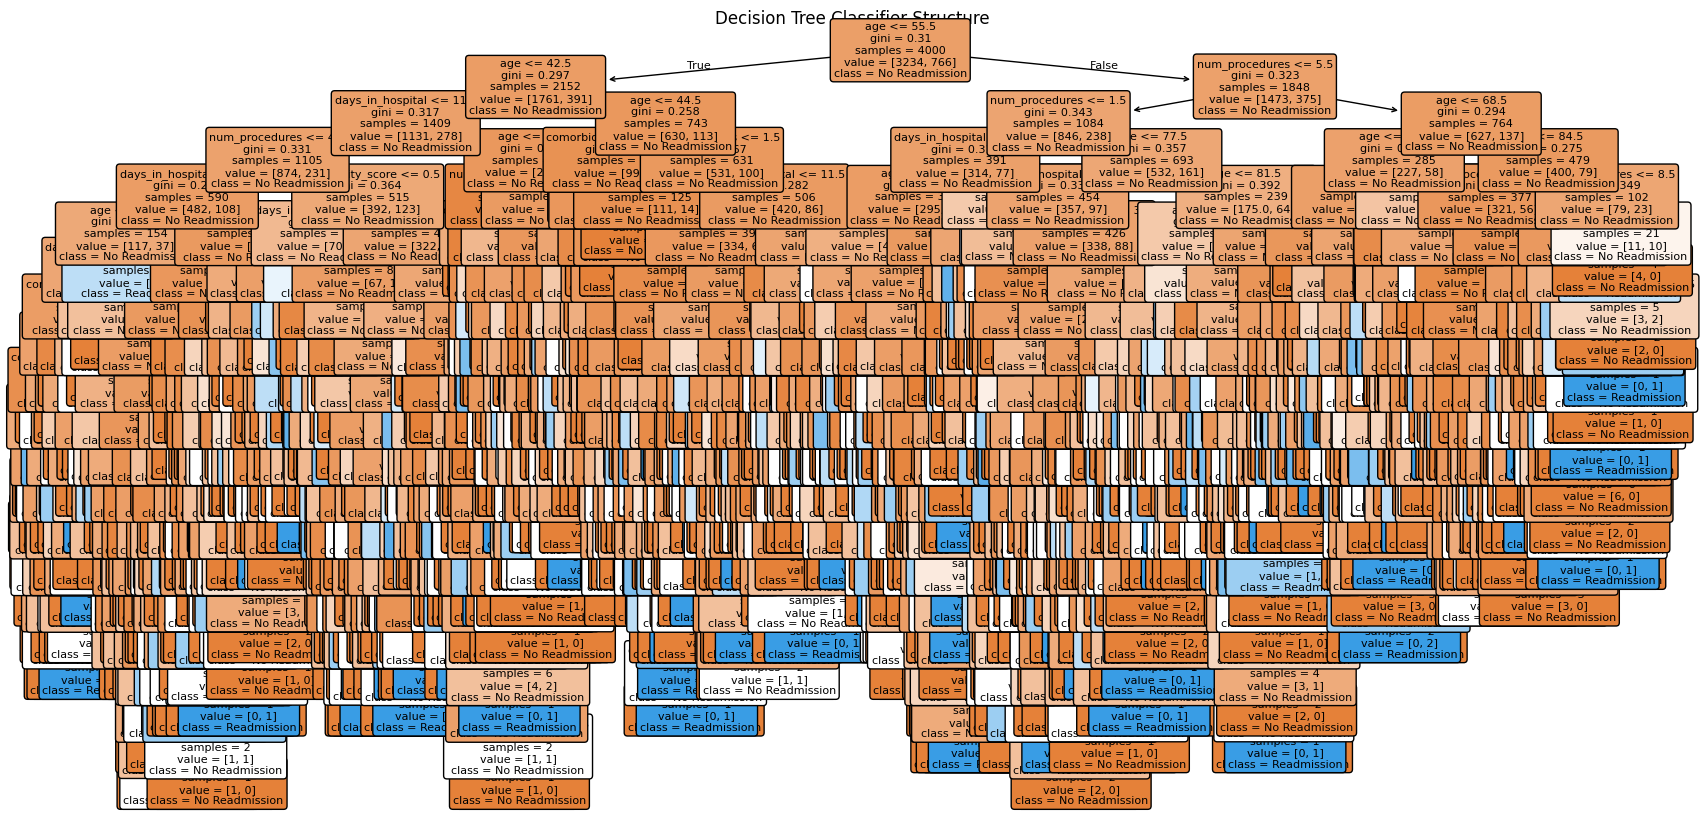


Decision Tree Rules:
|--- age <= 55.50
|   |--- age <= 42.50
|   |   |--- days_in_hospital <= 11.50
|   |   |   |--- num_procedures <= 4.50
|   |   |   |   |--- days_in_hospital <= 3.50
|   |   |   |   |   |--- age <= 41.50
|   |   |   |   |   |   |--- days_in_hospital <= 2.50
|   |   |   |   |   |   |   |--- comorbidity_score <= 3.50
|   |   |   |   |   |   |   |   |--- age <= 22.00
|   |   |   |   |   |   |   |   |   |--- comorbidity_score <= 1.50
|   |   |   |   |   |   |   |   |   |   |--- comorbidity_score <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |   |   |   |   |   |--- comorbidity_score >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |   |--- comorbidity_score >  1.50
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |--- age >  22.00
|   |   |   |   |   |   |   |   |   |--- age <= 26.50
|   |   |   |   |   |   |   |   |   |   |--

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, export_text

# Set figure size for better readability
plt.figure(figsize=(20, 10))

# Visualize the Decision Tree
plot_tree(dt_classifier,
          feature_names=selected_features,
          class_names=['No Readmission', 'Readmission'],
          filled=True,
          rounded=True,
          fontsize=8)

plt.title('Decision Tree Classifier Structure')
plt.show()

# Extract and display decision rules
tree_rules = export_text(dt_classifier, feature_names=selected_features)
print("\nDecision Tree Rules:")
print(tree_rules)

## Explain SVM (RBF) Decisions

### Subtask:
Provide an explanation of how the Support Vector Machine with an RBF kernel makes decisions. This might involve discussing the concept of support vectors and the non-linear decision boundary.


### Explaining Support Vector Machine (RBF) Decisions

Support Vector Machines (SVMs) are powerful supervised learning models used for classification and regression tasks. When equipped with a Radial Basis Function (RBF) kernel, they can effectively model complex, non-linear relationships in data.

1.  **Fundamental Principle of SVMs (Optimal Hyperplane and Margin)**:
    At its core, an SVM aims to find an optimal hyperplane that best separates data points belonging to different classes. For a binary classification problem (like 'High Risk' vs. 'Low Risk' readmission), the hyperplane is a decision boundary. The 'optimal' hyperplane is the one that maximizes the margin, which is the distance between the hyperplane and the nearest data points from each class. These nearest data points are called support vectors. Maximizing this margin helps to improve the generalization ability of the model, making it more robust to new, unseen data.

2.  **Role of the Radial Basis Function (RBF) Kernel for Non-Linearity**:
    Linear SVMs work well when classes are linearly separable. However, in many real-world scenarios, including readmission prediction, the relationship between features and the target variable is often non-linear. This is where kernel functions, like the Radial Basis Function (RBF) kernel, become crucial. The RBF kernel (also known as the Gaussian kernel) implicitly transforms the input features into a much higher-dimensional feature space. In this higher-dimensional space, data points that were not linearly separable in the original space might become linearly separable. The SVM then finds a linear decision boundary (hyperplane) in this transformed space, which, when mapped back to the original feature space, corresponds to a non-linear decision boundary.
    The mathematical form of the RBF kernel for two data points `x` and `x'` is `K(x, x') = exp(-gamma * ||x - x'||^2)`, where `gamma` is a parameter that defines how much influence a single training example has.

3.  **Significance of 'Support Vectors'**:
    Support vectors are the data points from the training set that are closest to the decision boundary (hyperplane) or that lie on the wrong side of the margin. These are the critical data points because they directly influence the position and orientation of the hyperplane and the width of the margin. All other data points, which are further away from the margin, do not affect the hyperplane's definition. This makes SVMs particularly memory efficient, as they only need to store the support vectors (and their corresponding weights) to make predictions on new data, rather than the entire training dataset. For our readmission prediction model, a patient whose characteristics align with a support vector would be a key case influencing whether the model predicts 'High Risk' or 'Low Risk'.

4.  **Collective Decision-Making for Readmission Risk Prediction**:
    An SVM (RBF) model makes predictions for readmission risk by first implicitly mapping a patient's features (e.g., age, days in hospital, comorbidity score) into a higher-dimensional space using the RBF kernel. In this new space, it uses the learned optimal hyperplane, which is defined by the support vectors from the training data, to classify the patient. If the patient's transformed features fall on one side of the hyperplane, they are classified as 'High Risk' for readmission; if they fall on the other side, they are classified as 'Low Risk'. The non-linear decision boundary in the original feature space, derived from the RBF kernel, allows the model to capture complex interactions between patient characteristics that might indicate readmission risk, going beyond simple linear relationships. This enables a more nuanced and potentially accurate prediction of readmission risk by identifying intricate patterns in the data.

## Final Task

### Subtask:
Summarize the performance of both models, discuss the insights from feature importance, and recap the decision explanation for each model.


## Summary:

### Data Analysis Key Findings

*   **Data Preparation:** Datasets (`train_df.csv` and `test_df.csv`) were successfully loaded. No missing values were found. Categorical features (`gender`, `primary_diagnosis`, `discharge_to`) were one-hot encoded, resulting in `train_df_encoded` with (5000, 13) features and `test_df_encoded` with (2000, 12) features, with consistent column alignment.
*   **Problem Definition:** Readmission prediction was defined as a binary classification problem, where 'High Risk' corresponds to readmission (positive class) and 'Low Risk' to no readmission (negative class).
*   **Feature Selection:** Using a Decision Tree Classifier, the top 5 most important features for predicting readmission were identified as `age`, `days_in_hospital`, `num_procedures`, `comorbidity_score`, and `gender_Male`.
*   **Decision Tree Classifier Performance:**
    *   The model achieved an overall Accuracy of 0.6860 on the test set.
    *   For the 'readmission' class (class 1), performance was low: Precision of 0.1875, Recall of 0.2414, and F1-Score of 0.2111. This indicates the model struggles to accurately identify readmissions.
*   **Support Vector Machine (RBF) Classifier Performance:**
    *   Initial training without class weighting resulted in zero positive predictions (class 1), indicating severe class imbalance.
    *   After applying `class_weight='balanced'`, the model's overall Accuracy was 0.4530.
    *   For the 'readmission' class (class 1), the balanced model showed a Recall of 0.5747 (a significant improvement), but a low Precision of 0.1745 and an F1-Score of 0.2677. This means while it identifies more actual readmissions, it also has a high rate of false positives.
*   **Decision Tree Explanation:** The decision-making process of the Decision Tree Classifier was visualized and its rules extracted, showing a hierarchical structure based on the selected features to classify readmission risk.
*   **SVM (RBF) Explanation:** The explanation detailed how SVMs with an RBF kernel make decisions by finding an optimal hyperplane that maximizes the margin, implicitly mapping data to a higher-dimensional space for non-linear separation, and relying on 'support vectors' as critical data points defining the decision boundary.

### Insights or Next Steps

*   Both models, particularly the Decision Tree, show poor precision for predicting readmissions, indicating a high number of false positives. The SVM with balanced class weights significantly improved recall for the minority class but at the cost of overall accuracy and still struggles with precision. This highlights the challenge of predicting the minority class accurately in imbalanced datasets.
*   Further efforts should focus on advanced techniques to address class imbalance (e.g., SMOTE, undersampling the majority class with more sophisticated methods), extensive hyperparameter tuning for both models (especially `gamma` and `C` for SVM, and tree depth for Decision Tree), and potentially exploring other models better suited for imbalanced classification or considering an ensemble approach.
